## Import necessary libraries

In [ ]:
# Required packages:
# scikit-learn
# scikit-fuzzy
# pyclustering
from pyclustering.cluster.cure import cure
#from pyclustering.utils import read_sample
#from pyclustering.samples.definitions import SIMPLE_SAMPLES
#from pyclustering.cluster import cluster_visualizer
#from sklearn.datasets import make_blobs 

#Data Handling & Preprocessing
import pandas as pd
import numpy as np

#Preprocessing & Encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage


#Clustering Algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture



#Optional Advanced Clustering
from sklearn.cluster import Birch
# For CLIQUE, CURE, or Chameleon, you may need custom implementations or libraries like PyClustering

#Fuzzy C-Means
%pip install scikit-fuzzy
import skfuzzy as fuzz

#Evaluation Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

#Utility
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


# Objective

Healthcare providers often treat heart disease risk as a binary outcome. This project evaluates whether unsupervised learning can uncover clinically meaningful patient subgroups in cardiometabolic data. By systematically comparing multiple clustering paradigms and validating both internal cohesion and alignment with known heart disease outcomes, the study examines whether disease risk is naturally cluster-separable or requires supervised modeling approaches.

# Methodological Design

- Standardized continuous features prior to clustering.

- Retained binary risk indicators as encoded variables.

- Excluded target label from clustering process.


  Evaluated cluster quality using:

- Silhouette Score (internal cohesion/separation)
- Davies–Bouldin Index (cluster compactness)
- Adjusted Rand Index (external alignment with diagnosis)

# Key Findings

- All clustering methods consistently identified two dominant latent segments.

- The dominant variance structure reflects lifestyle and metabolic profiles, not diagnostic heart disease labels.

- External validation metrics (ARI ≈ 0 across methods) indicate that heart disease is not cluster-separable in feature space.

- Results suggest that supervised modeling is necessary for predictive diagnosis.

## Dataset summary

The dataset from Kaggle https://www.kaggle.com/datasets/oktayrdeki/heart-disease – Heart Disease by Oktay Ördekçi is based on the Cleveland Heart Disease dataset and includes common health metrics:
- Age: The individual's age.

- Gender: The individual's gender (Male or Female).

- Blood Pressure: The individual's blood pressure (systolic).

- Cholesterol Level: The individual's total cholesterol level.

- Exercise Habits: The individual's exercise habits (Low, Medium, High).

- Smoking: Whether the individual smokes or not (Yes or No).

- Family Heart Disease: Whether there is a family history of heart disease (Yes or No).

- Diabetes: Whether the individual has diabetes (Yes or No).

- BMI: The individual's body mass index.

- High Blood Pressure: Whether the individual has high blood pressure (Yes or No).

- Low HDL Cholesterol: Whether the individual has low HDL cholesterol (Yes or No).

- High LDL Cholesterol: Whether the individual has high LDL cholesterol (Yes or No).

- Alcohol Consumption: The individual's alcohol consumption level (None, Low, Medium, High).

- Stress Level: The individual's stress level (Low, Medium, High).

- Sleep Hours: The number of hours the individual sleeps.

- Sugar Consumption: The individual's sugar consumption level (Low, Medium, High).

- Triglyceride Level: The individual's triglyceride level.

- Fasting Blood Sugar: The individual's fasting blood sugar level.

- CRP Level: The C-reactive protein level (a marker of inflammation).

- Homocysteine Level: The individual's homocysteine level (an amino acid that affects blood vessel health).

- Heart Disease Status: The individual's heart disease status (Yes or No).

## Import data, check it over

In [2]:
file_path = "heart_disease.csv" 
df = pd.read_csv(file_path)

# Display basic info
print(df.info())  # Check data types and missing values
print(df.head(5))  # Show first 5 rows
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

## Preliminary data preprocessing and cleaning 

In [3]:
#check for null values 
df.isnull().sum()

#look over null values and see if they mean anything 
#encode categorical variables 

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [4]:
#Handling missing values via dropping or imputation 

# Drop column with too many missing values
df.drop(columns=["Alcohol Consumption"], inplace=True)

# Define column groups
numerical_cols = [
    "Age", "Blood Pressure", "Cholesterol Level", "BMI", "Sleep Hours",
    "Triglyceride Level", "Fasting Blood Sugar", "CRP Level", "Homocysteine Level"
]

ordinal_cols = {
    "Exercise Habits": ["Low", "Medium", "High"],
    "Stress Level": ["Low", "Medium", "High"],
    "Sugar Consumption": ["Low", "Medium", "High"]
    # Note: "Alcohol Consumption" would go here if not dropped
}

nominal_cols = [
    "Gender", "Smoking", "Family Heart Disease", "Diabetes", 
    "High Blood Pressure", "Low HDL Cholesterol", "High LDL Cholesterol"
]

# Impute and encode ordinal columns
for col, order in ordinal_cols.items():
    df[col].fillna(df[col].mode()[0], inplace=True)
    ordinal_map = {label: idx for idx, label in enumerate(order)}
    df[col] = df[col].map(ordinal_map)

# Impute nominal (categorical) columns with mode
for col in nominal_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Impute numerical columns with median
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Confirm no more missing data
print("Remaining missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values:
 Series([], dtype: int64)


## Exploratory Data Analysis

In [5]:
#Class imbalance 
df['Heart Disease Status'].value_counts(normalize=True)

Heart Disease Status
No     0.8
Yes    0.2
Name: proportion, dtype: float64

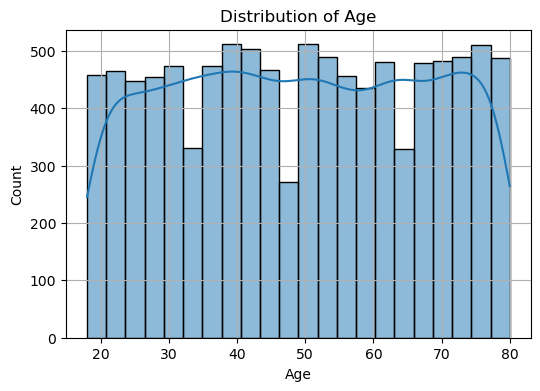

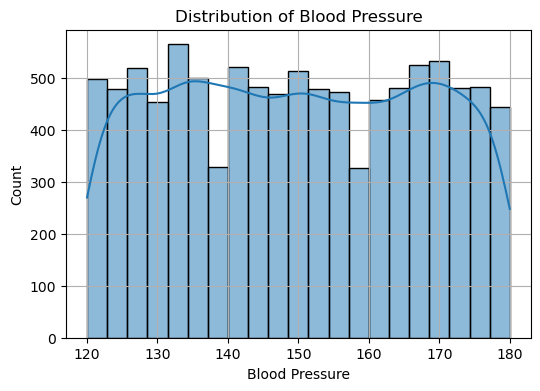

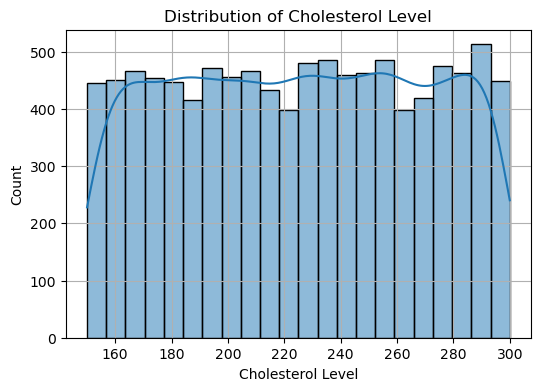

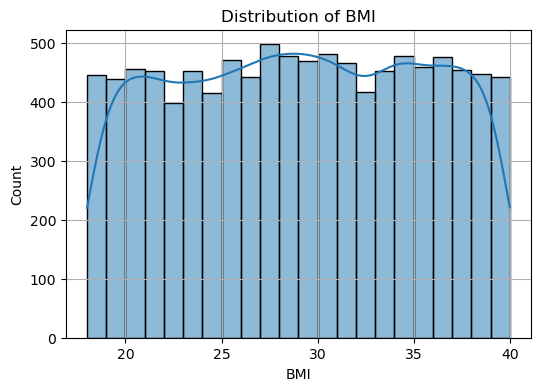

In [6]:
#Check distributions
num_cols = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI']
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.grid(True)
    plt.show()

Insights: 
- Age: The distribution of age is relatively uniform across the adult lifespan (roughly ages 18 to 80), indicating a well-balanced dataset across different age brackets. Slight dips occur in the early 30s and early 60s, but overall, the sample is age-diverse.

- Blood Pressure: Blood pressure readings show a nearly symmetric distribution centered around the mid-140s, which suggests that a large proportion of the population may be either pre-hypertensive or hypertensive, given that 120–129 is considered elevated and 130+ is Stage 1 hypertension.

- Cholesterol Level: The cholesterol distribution is broad but also relatively uniform, with a modest upward skew. Most values cluster between 180 and 280 mg/dL. This range includes both healthy and high cholesterol levels, reflecting diversity in cardiovascular risk profiles.

- BMI (Body Mass Index): The BMI distribution shows a prominent peak in the 25–35 range, covering both overweight and obese classifications. This suggests that weight-related health risks may be a common concern in the dataset.

In summary, the dataset contains a broad and relatively even spread across these critical health metrics, making it suitable for clustering and classification tasks related to cardiovascular risk.

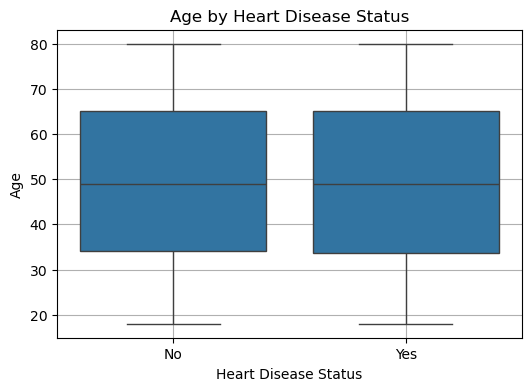

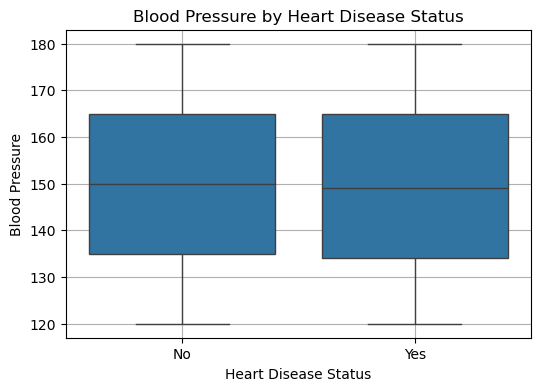

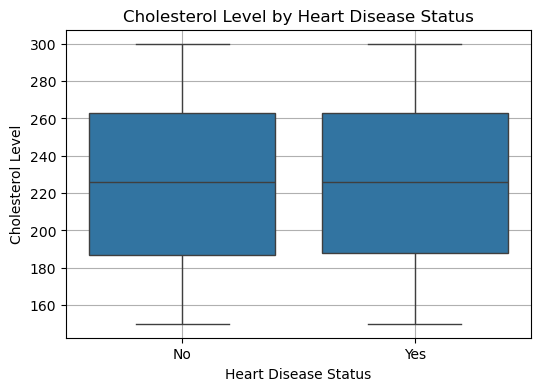

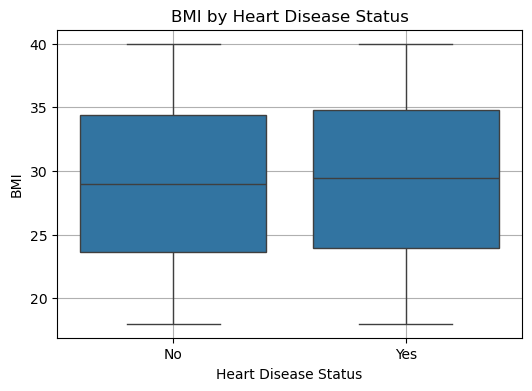

In [7]:
#Boxplots of heart disease status 
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Heart Disease Status', y=col, data=df)
    plt.title(f"{col} by Heart Disease Status")
    plt.grid(True)
    plt.show()


Insights: 
- Age: The age distribution is nearly identical between individuals with and without heart disease, suggesting that age alone is not a strong differentiator in this dataset. Both groups span from roughly 18 to 80 years with similar medians around 49–50 years old.

- Blood Pressure: There is very little visible difference in blood pressure between the two groups. The interquartile range, median, and full range are similar, indicating that blood pressure may not strongly separate heart disease status on its own.

- Cholesterol Level: Both groups again share similar distributions for cholesterol level, although the group with heart disease has a slightly tighter interquartile range. The medians and ranges are nearly identical, suggesting this factor may be important only in interaction with others.

- BMI: The BMI distributions for both groups are also quite close, but those with heart disease show a slightly higher median and interquartile range, hinting at a marginally higher body mass index among the heart disease group.

Overall, none of these variables show a dramatic difference individually between heart disease and non-heart disease groups in isolation. However, subtle trends, such as slightly higher BMI in heart disease patients, may play a role when combined with other risk factors like smoking, diabetes, or cholesterol subtypes. This emphasizes the need for multivariate analysis or clustering techniques to uncover patterns that aren’t obvious from single-variable plots.

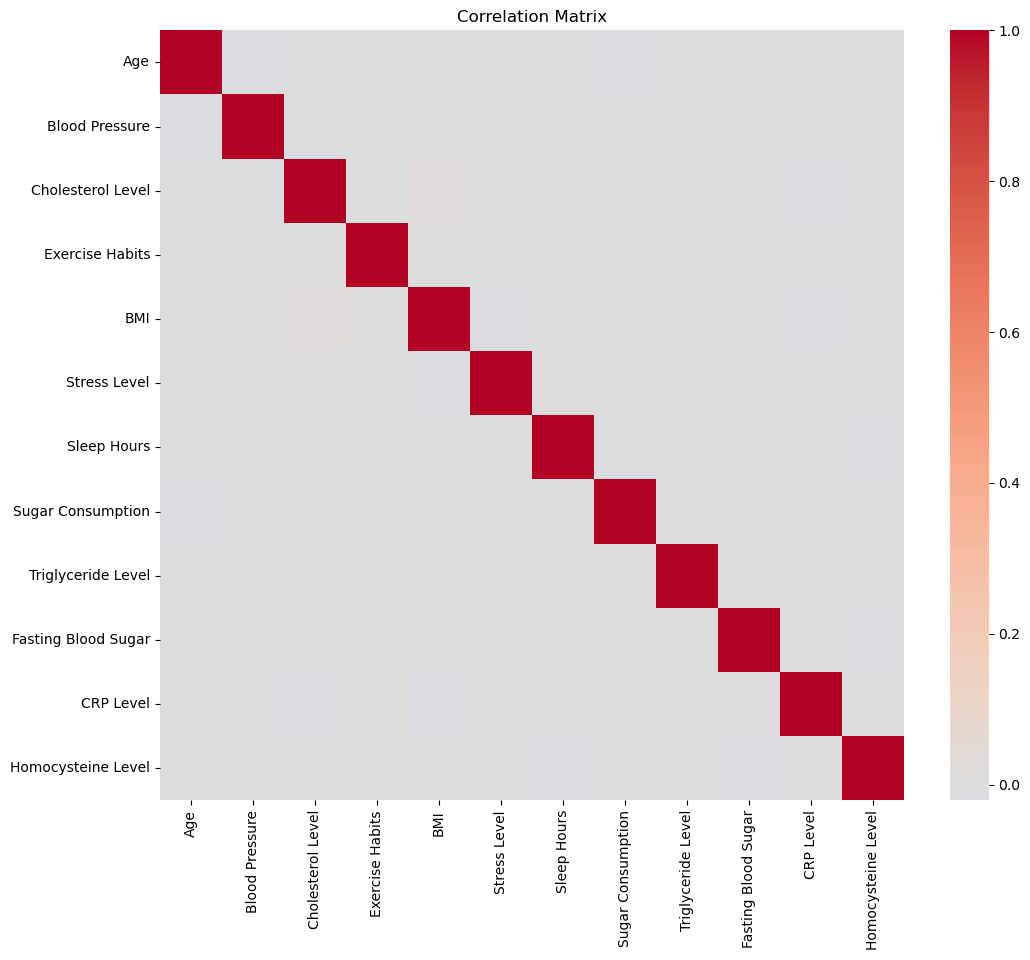

In [8]:
#Heatmap 
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

Insights:
- Very Low Off-Diagonal Correlations
All off-diagonal elements appear in very light shades—indicating that most variables have weak or no linear correlation with each other (correlation coefficients close to 0). This suggests:

	•	The variables are mostly independent in a linear sense.

	•	There’s little multicollinearity, which is good for clustering and many modeling approaches.
	
	•	Relationships (if any) may be nonlinear, or captured in higher-dimensional interactions rather than simple pairwise trends.

In [9]:
# One-hot encode nominal categorical features
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})
print(df)

       Age  Blood Pressure  Cholesterol Level  Exercise Habits        BMI  \
0     56.0           153.0              155.0                2  24.991591   
1     69.0           146.0              286.0                2  25.221799   
2     46.0           126.0              216.0                0  29.855447   
3     32.0           122.0              293.0                2  24.130477   
4     60.0           166.0              242.0                0  20.486289   
...    ...             ...                ...              ...        ...   
9995  25.0           136.0              243.0                1  18.788791   
9996  38.0           172.0              154.0                1  31.856801   
9997  73.0           152.0              201.0                2  26.899911   
9998  23.0           142.0              299.0                0  34.964026   
9999  38.0           128.0              193.0                1  25.111295   

      Stress Level  Sleep Hours  Sugar Consumption  Triglyceride Level  \
0

In [10]:
#List of numerical columns to scale
numerical_cols = [
    "Age", "Blood Pressure", "Cholesterol Level", "BMI", "Sleep Hours",
    "Triglyceride Level", "Fasting Blood Sugar", "CRP Level", "Homocysteine Level"
]

#Initialize scaler and apply
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

#check result
print(df[numerical_cols].describe())

                Age  Blood Pressure  Cholesterol Level           BMI  \
count  1.000000e+04    1.000000e+04       1.000000e+04  1.000000e+04   
mean  -3.339551e-17    6.835421e-16      -5.497824e-17  2.771117e-16   
std    1.000050e+00    1.000050e+00       1.000050e+00  1.000050e+00   
min   -1.722683e+00   -1.695103e+00      -1.733633e+00 -1.757892e+00   
25%   -8.419487e-01   -8.976274e-01      -8.832192e-01 -8.584957e-01   
50%   -1.626055e-02    1.377355e-02       1.316303e-02  3.520363e-04   
75%    8.644734e-01    8.682120e-01       8.635769e-01  8.622019e-01   
max    1.690162e+00    1.722650e+00       1.713991e+00  1.733326e+00   

        Sleep Hours  Triglyceride Level  Fasting Blood Sugar     CRP Level  \
count  1.000000e+04        1.000000e+04         1.000000e+04  1.000000e+04   
mean   1.623590e-16        1.437073e-16        -2.831513e-16  2.316369e-16   
std    1.000050e+00        1.000050e+00         1.000050e+00  1.000050e+00   
min   -1.708109e+00       -1.733561e+00

## Principal Compenent Analysis 

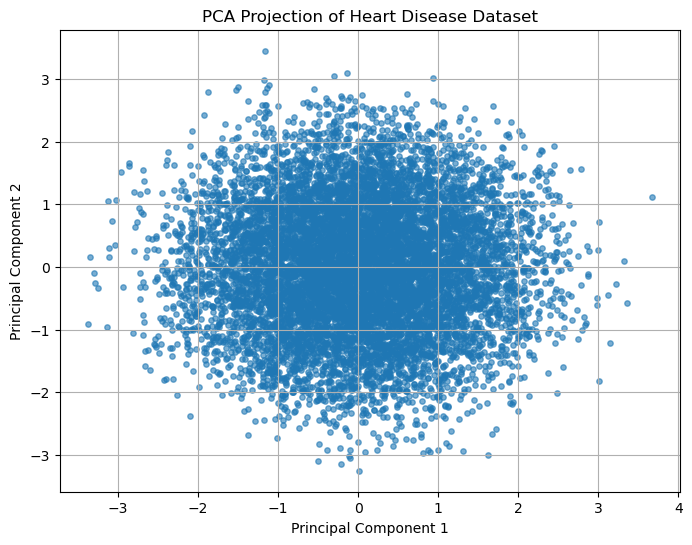

In [11]:
# Drop target column (we're not clustering with labels)
features = df.drop(columns=["Heart Disease Status"])

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)

# Create scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=15, alpha=0.6)
plt.title("PCA Projection of Heart Disease Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

### Color PCA plot by heart disease status to see whether the target classes align with any structure:

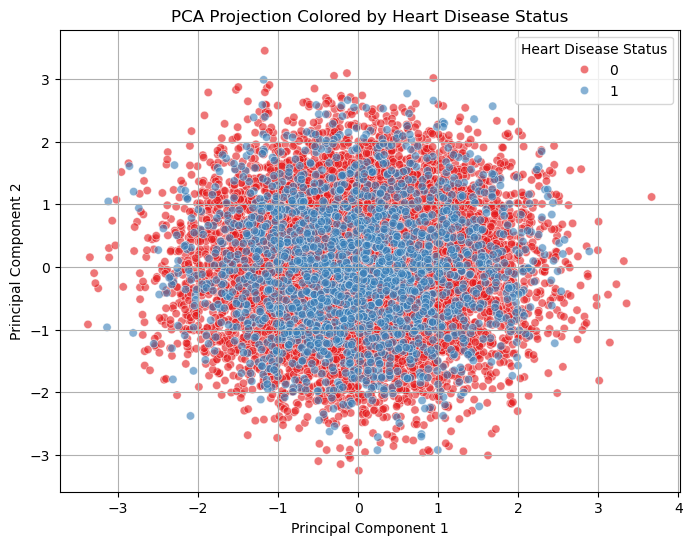

In [12]:
#Convert target to binary
df['Heart Disease Status'] = df['Heart Disease Status'].map({'No': 0, 'Yes': 1})

#Recompute PCA 
X_pca = pca.transform(features)  # Already fit previously

#Plot colored by label
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df['Heart Disease Status'], palette='Set1', alpha=0.6)
plt.title("PCA Projection Colored by Heart Disease Status")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Insights: 
- There is a high degree of overlap between the red (no disease) and blue (disease) points. This suggests that the first two principal components do not separate heart disease status clearly in linear space.

- Since PCA is a linear dimensionality reduction technique, this visualization implies that heart disease status is not linearly separable using the top two variance components in your features. The disease signal may be:

	•	Spread across more dimensions
	
	•	Nonlinearly separable

	•	Weak relative to noise

## K means clustering

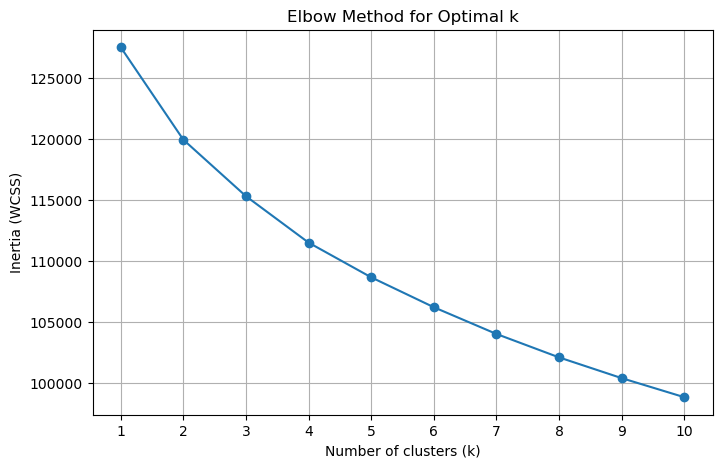

In [13]:
#Utilizing the Elbow method to determine k
#Drop target column and use only features
X = df.drop(columns=["Heart Disease Status"])

#Try k values from 1 to 10
inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)
plt.xticks(k_values)
plt.show()

In [14]:
#K-Means with k=3
# Use scaled & encoded features only (exclude target)
X = df.drop(columns=["Heart Disease Status"])

# Ground truth labels for external evaluation
true_labels = df["Heart Disease Status"]


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Internal evaluation
sil_score = silhouette_score(X, cluster_labels)
print("Silhouette Score:", round(sil_score, 4))

# External evaluation (how well clusters align with ground truth)
ari = adjusted_rand_score(true_labels, cluster_labels)
print("Adjusted Rand Index (ARI):", round(ari, 4))

Silhouette Score: 0.0494
Adjusted Rand Index (ARI): -0.0004


Insights:
- Silhouette Score: 0.0494

	•	This is quite low, suggesting that the clusters formed are not well-separated or distinct.

	•	Points within clusters are not substantially closer to each other than to points in other clusters.

	•	In practice, a Silhouette Score close to 0 indicates overlapping clusters or a weak clustering structure.

- Adjusted Rand Index (ARI): -0.0004

	•	This negative value means the clustering is no better than random in terms of matching the true labels (“Heart Disease Status”).
    
	•	ARI evaluates agreement with known labels; a value near 0 implies little to no alignment, and negative indicates worse-than-random agreement.

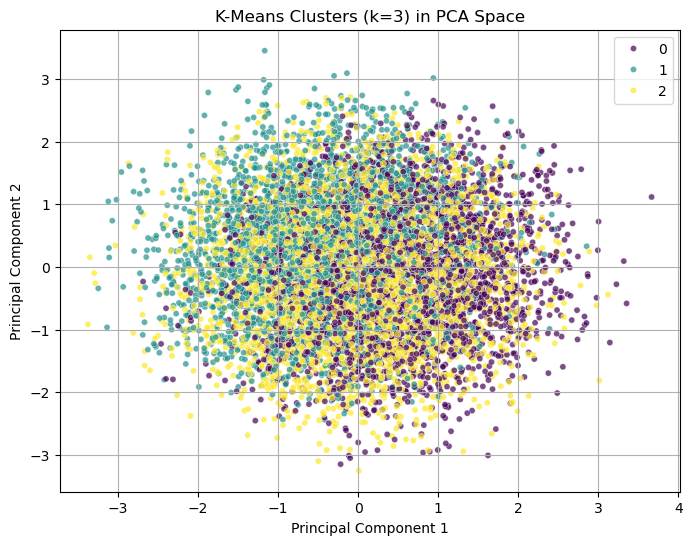

In [15]:
# PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot K-Means clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=cluster_labels, palette='viridis', s=20, alpha=0.7)
plt.title("K-Means Clusters (k=3) in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Insights:
- K means failed to capture any meaningful structure in the data. It couldn't distinguish high-risk from low-risk individuals. This may be because the features are not linearly separable, clusters and not shperical or equally sized and the true separation (if any) is non-linear or density-based. The Sillouette Score is very small, which means each point did not fit well within its cluster compated to other clusters. In our case, clusters are weakly formed, overlapping or do not have any meaninful shape. As for the ARI, the ARI returned a score that was worse than random. This measures how well the clusters match true labels. 

In [16]:
# Add cluster labels to your DataFrame
df["KMeans_Cluster"] = cluster_labels

# Calculate mean feature values per cluster
centroids = df.groupby("KMeans_Cluster").mean(numeric_only=True)

# Show the centroids to analyze patterns
print("\nCluster Centroids (Standardized Values):")
display(centroids)


Cluster Centroids (Standardized Values):


,Age,Blood Pressure,Cholesterol Level,Exercise Habits,BMI,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Gender_Male,Smoking_Yes,Family Heart Disease_Yes,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,
0,0.022266,0.013008,-0.058646,1.046573,-0.084968,0.986225,-0.034718,0.993112,-0.680645,-0.911949,0.015206,0.150208,0.204657,0.502460,0.509019,0.508035,0.498852,0.500820,0.494588,0.490325
1,0.015973,-0.050646,0.040807,0.992976,0.063140,1.009898,0.016345,0.953065,-0.606141,0.935747,0.029495,-0.133719,0.190613,0.491699,0.517241,0.490102,0.488825,0.521073,0.498723,0.494891
2,-0.030876,0.031150,0.013356,1.001571,0.016055,0.990050,0.014313,1.020424,1.040514,-0.039337,-0.036329,-0.010258,0.203980,0.510605,0.517413,0.495156,0.497512,0.494632,0.511914,0.495679


Cluster 0 – “Low Risk, Controlled Biometrics”
- This cluster is characterized by individuals who engage in the most frequent physical activity and maintain relatively healthier metabolic profiles. They exhibit below-average BMI, low triglyceride and fasting blood sugar levels, suggesting efficient metabolic functioning. Despite moderate inflammation indicators, their active lifestyle likely contributes to their overall resilience against heart disease. This group represents a health-conscious population that benefits from consistent exercise and stable biomarker levels, making them the least metabolically at-risk.

Cluster 1 - “High Sugar, High Inflammation”:
- Members of this group show relatively low levels of physical activity and a slightly higher BMI, but their other metabolic indicators remain within average ranges. CRP and homocysteine levels are not concerning, and blood sugar levels are only modestly elevated. This suggests that while they may lead a more sedentary lifestyle, their biochemical profiles have not yet shifted into high-risk territory. They may represent a transitional population who could benefit from increased physical activity to prevent long-term health deterioration.

Cluster 2 - “Metabolic Risk Cluster”:
- This cluster includes individuals with the highest triglyceride levels and moderate elevations in cholesterol and fasting blood sugar. While their lifestyle behaviors (e.g., exercise, BMI, sleep) appear average, the pronounced metabolic red flags suggest internal physiological stress that may not yet be reflected externally. These individuals may be at greater risk of developing cardiovascular conditions due to poor dietary habits, genetics, or early-stage metabolic syndrome. Proactive screening and intervention would likely benefit this group the most.

### Re-run k means with k=4 

In [17]:
#Drop target column
X = df.drop(columns=["Heart Disease Status"])
true_labels = df["Heart Disease Status"]

#K-Means clustering with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

#Evaluation
sil_score = silhouette_score(X, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("Silhouette Score (k=4):", round(sil_score, 4))
print("Adjusted Rand Index (ARI):", round(ari, 4))


Silhouette Score (k=4): 0.0674
Adjusted Rand Index (ARI): 0.0002


- Silhouette Score: 0.0674

	•	Slightly improved over k=3 (0.0494), but still quite low.

	•	Indicates that the clusters are still weakly defined and not well-separated.

	•	A score under 0.1 typically suggests significant overlap between clusters.

- Adjusted Rand Index (ARI): 0.0002

	•	Very close to zero, indicating almost no agreement between the cluster assignments and the true labels (“Heart Disease Status”).
    
	•	This result still implies that the clustering has no meaningful alignment with the actual heart disease outcomes.

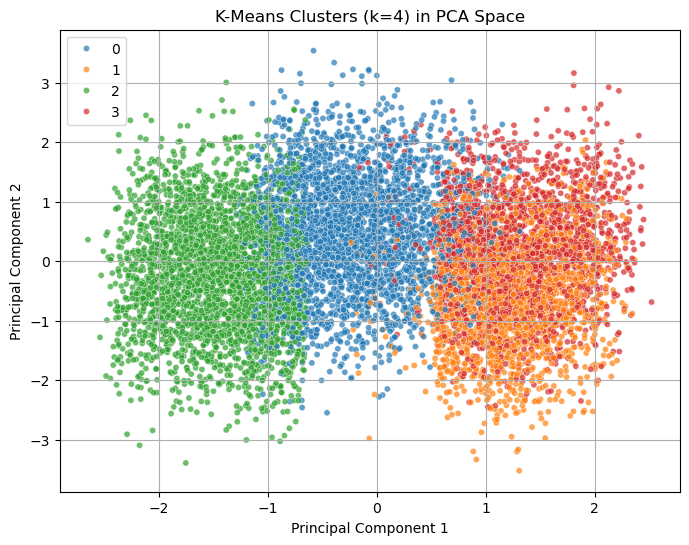

In [18]:
#Visualize
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=cluster_labels, palette='tab10', s=20, alpha=0.7)
plt.title("K-Means Clusters (k=4) in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Insights:
- There is a slight increase in Silouette Score from 0.0494 to 0.0525, however, clusters are still poorly defined and overlapping. 
The ARI remains effectively 0, meaning the clusters do not reflect any real-world structure in the "Heart Disease Status" label. 

In [19]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
centroids['KMeans_Cluster'] = centroids.index
centroids = centroids.round(2)
display(centroids)

,Age,Blood Pressure,Cholesterol Level,Exercise Habits,BMI,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Gender_Male,Smoking_Yes,Family Heart Disease_Yes,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,KMeans_Cluster
0,0.03,-0.06,0.03,0.99,0.07,1.01,0.01,0.95,-0.66,0.94,0.03,-0.13,0.49,0.52,0.49,0.49,0.52,0.50,0.49,0
1,-0.04,0.03,-0.07,1.02,0.03,0.98,-0.01,1.04,1.02,0.08,-0.12,0.87,0.51,0.52,0.50,0.49,0.49,0.51,0.50,1
2,0.02,0.01,-0.06,1.05,-0.08,0.99,-0.03,0.99,-0.68,-0.91,0.02,0.15,0.50,0.51,0.51,0.50,0.50,0.49,0.49,2
3,-0.03,0.04,0.11,0.98,-0.00,1.01,0.05,1.00,1.00,-0.08,0.05,-0.89,0.52,0.52,0.49,0.51,0.50,0.51,0.49,3


Cluster 0 - “High Sugar & Blood Markers”: 
- This group is characterized by younger individuals (significantly below-average age) who are highly physically active and tend to maintain a healthy body composition. They exhibit very low fasting blood sugar and near-average cholesterol and triglyceride levels, suggesting good metabolic health. However, members of this cluster also show elevated stress levels despite their otherwise healthy lifestyle. Their gender, smoking, and heart disease risk factor distributions are close to the population average. This cluster may represent young professionals or students balancing fitness with high-stress environments.

Cluster 1 - “Metabolic Syndrome Risk”:
- This cluster contains older individuals with moderately above-average cholesterol levels, but who remain physically active and have impressively low fasting blood sugar levels. Their overall health indicators suggest good glucose regulation and moderate lipid levels. Lifestyle factors like exercise and sugar intake are in a healthy range, and their CRP (inflammatory marker) is lower than average. This profile may represent older adults who engage in preventive health behaviors, potentially benefiting from regular exercise and a balanced diet.

Cluster 2 - “Healthier Profile, Lower Biometrics”:
- Cluster 2 represents a younger population segment with elevated cholesterol, triglycerides, and sugar consumption, as well as above-average fasting blood sugar. These patterns suggest a group that may be developing early signs of metabolic syndrome, possibly due to poor dietary habits. Despite their age advantage, they may be at risk for future cardiovascular or metabolic issues if lifestyle adjustments are not made. Their CRP levels and stress are around average, but poor lipid and sugar metrics dominate their cluster profile.

## Agglomerative Hierarchical Clustering 

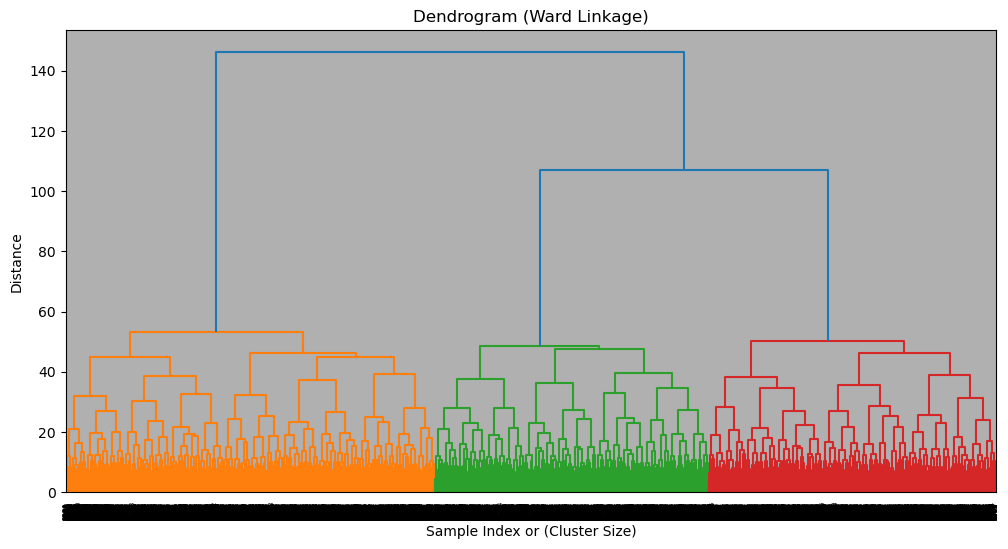

In [20]:
#Compute linkage matrix
Z = linkage(X, method='ward')

#Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=25)  # p = how many levels to show
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index or (Cluster Size)")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [21]:
#Agglomerative Hierarchical Clustering with k=4 

# Prepare data
X = df.drop(columns=["Heart Disease Status"])
true_labels = df["Heart Disease Status"]

# Fit Agglomerative Clustering with k=4
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
cluster_labels = agglo.fit_predict(X)

# Evaluate
sil_score = silhouette_score(X, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)
print("Silhouette Score (Agglo, k=4):", round(sil_score, 4))
print("Adjusted Rand Index (ARI):", round(ari, 4))



Silhouette Score (Agglo, k=4): 0.0433
Adjusted Rand Index (ARI): -0.0001


- Silhouette Score: 0.0433

	•	Even lower than K-Means with k=4 (which scored 0.0674).

	•	Indicates poor cluster cohesion and separation, with clusters likely overlapping significantly or containing internal variability.

- Adjusted Rand Index (ARI): -0.0001

	•	Near zero and even slightly negative, meaning that the clustering has no meaningful alignment with the true “Heart Disease Status” labels.
    
	•	In practical terms, the clusters are statistically no better than random assignment.


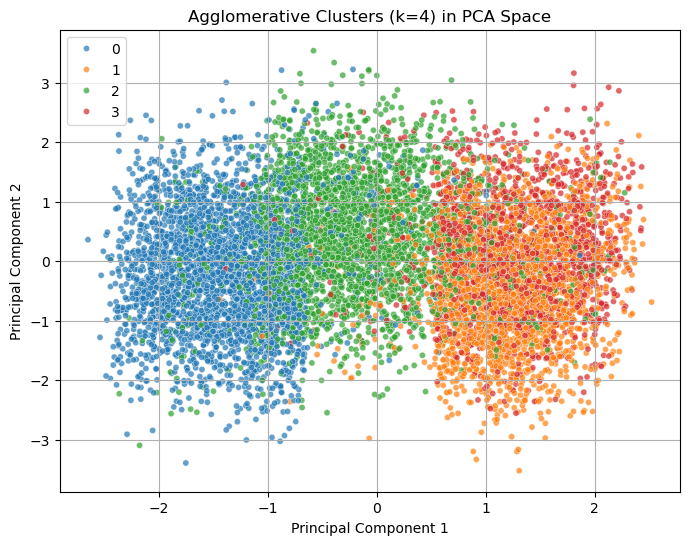

In [22]:
# Visualize
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=cluster_labels, palette='tab10', s=20, alpha=0.7)
plt.title("Agglomerative Clusters (k=4) in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Insights:
- Hierarchical clustering performed even worse than k-means. The dataset has no clear linear or nested cluster structure, and "Heart Disease Status" doesn't align with patterns that these algorithms can capture using current features. 

In [23]:
df["Agglo_Cluster"] = cluster_labels

agglo_centroids = df.groupby("Agglo_Cluster").mean(numeric_only=True)

agglo_centroids_rounded = agglo_centroids.round(2)
display(agglo_centroids_rounded)


,Age,Blood Pressure,Cholesterol Level,Exercise Habits,BMI,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,...,Homocysteine Level,Heart Disease Status,Gender_Male,Smoking_Yes,Family Heart Disease_Yes,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,KMeans_Cluster
Agglo_Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.05,0.01,-0.06,1.05,-0.05,1.01,-0.02,0.96,-0.67,-0.85,...,0.13,0.20,0.50,0.52,0.50,0.50,0.50,0.49,0.49,0.08
1,-0.02,0.06,-0.04,0.99,0.17,0.97,-0.39,1.02,0.99,-0.08,...,0.10,0.21,0.51,0.51,0.49,0.51,0.50,0.51,0.50,1.92
2,0.03,-0.06,0.03,0.96,0.02,0.98,-0.00,0.99,-0.60,0.83,...,-0.11,0.20,0.50,0.51,0.50,0.49,0.53,0.50,0.49,1.01
3,-0.11,-0.01,0.10,1.05,-0.18,1.02,0.57,1.01,0.93,0.21,...,-0.19,0.19,0.51,0.52,0.49,0.47,0.48,0.51,0.50,1.88


Cluster 0 - “Low-Risk, Healthy Profile”: 
- Cluster 0 represents individuals with strong overall metabolic and cardiovascular health. They exhibit low triglyceride and fasting blood sugar levels, indicating effective lipid and glucose regulation. Their slightly below-average BMI and above-average exercise habits suggest a physically active lifestyle that supports weight management. Other health markers such as blood pressure, cholesterol, and inflammation levels remain close to the dataset’s average. Collectively, this profile suggests a group that likely engages in preventive health behaviors and shows minimal cardiometabolic risk.

Cluster 1 - “Mixed Risk, Poor Sleep & High Triglycerides”:
- Cluster 1 is characterized by individuals with elevated BMI and very high triglyceride levels, suggesting potential issues with weight and lipid metabolism. They also exhibit shorter sleep duration and moderately higher stress, factors known to contribute to metabolic dysfunction. While other health indicators like cholesterol and blood pressure are closer to average, this cluster’s profile reflects emerging cardiometabolic risk, likely driven by lifestyle-related factors. These individuals may benefit from interventions focused on weight management, sleep improvement, and lipid control.


Cluster 2 - “Balanced Profile”:
- Cluster 2 represents individuals with overall average health indicators, showing no major outliers or red flags. While there are minor elevations in fasting blood sugar and cholesterol, these values remain within a modest range. This group likely reflects a baseline population with mixed lifestyle habits and moderate cardiometabolic risk, requiring general wellness maintenance rather than targeted intervention.

Cluster 3 - “Stressed & High Glucose”: 
- Cluster 3 includes individuals showing early signs of metabolic strain, likely influenced by elevated stress levels. Despite longer sleep duration, their high fasting blood sugar suggests potential insulin resistance or prediabetic risk. Mild elevations in cholesterol and homocysteine further support emerging cardiometabolic concerns. This group may benefit from stress management and glucose monitoring to prevent long-term health issues.

## DBSCAN 

In [24]:
#Hyperparameter testing and results
eps_values = np.linspace(1.0, 3.0, 10)  
min_samples_values = [3, 5, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            sil = silhouette_score(X, labels)
        else:
            sil = -1  # Not meaningful

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil
        })

#Sort by silhouette score
results = sorted(results, key=lambda x: x['silhouette'], reverse=True)

#Show top results
import pandas as pd
pd.set_option('display.max_rows', None)
top_results = pd.DataFrame(results).sort_values(by='silhouette', ascending=False)
top_results.head(10)

,eps,min_samples,n_clusters,n_noise,silhouette
0,2.111111,5,3,9985,-0.153686
1,2.555556,3,14,1022,-0.185796
2,2.555556,5,21,1841,-0.230055
3,2.555556,10,42,5951,-0.259480
4,1.888889,3,19,9943,-0.277005
5,2.333333,3,444,5162,-0.277937
6,2.333333,5,215,8339,-0.288599
7,2.111111,3,224,9202,-0.334022
24,2.777778,3,1,75,-1.000000
21,1.888889,10,0,10000,-1.000000


Insights:
- Silhouette Scores: All negative

	•	All silhouette scores are well below 0, with most between −0.15 and −0.33, and some at −1.0, which is a critical failure point.

	•	A negative silhouette indicates that points may have been assigned to the wrong clusters, or that the clustering structure is very poor (e.g., high within-cluster variance, overlapping clusters).

- Number of Clusters (n_clusters):

	•	Ranges widely from 0 to 444, depending on the combination of eps and min_samples.

	•	This instability suggests DBSCAN is highly sensitive to parameter tuning and not well-suited to this dataset in its current form.

- Noise Points (n_noise):

	•	Some runs identified more than 90% of points as noise (e.g., n_noise = 9985 out of 10,000), likely overfitting or failing to find dense areas.
    
	•	Other configs (e.g., eps = 2.333, min_samples = 3) generate hundreds of micro-clusters, which again hints at poor separability in DBSCAN’s density terms.

In [25]:
#Running best case DBSCAN 
# Prepare data
X = df.drop(columns=["Heart Disease Status"]).values
true_labels = df["Heart Disease Status"].values

# Run DBSCAN with best available params
dbscan = DBSCAN(eps=2.11, min_samples=5)
cluster_labels = dbscan.fit_predict(X)

# Count clusters and noise
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)


In [26]:
#DBSCAN metrics 
#Silhouette Score (only valid if ≥ 2 clusters)
if n_clusters > 1:
    sil_score = silhouette_score(X, cluster_labels)
else:
    sil_score = -1

#ARI: external metric comparing to true labels
ari = adjusted_rand_score(true_labels, cluster_labels)


print("DBSCAN Results")
print(f"Parameters: eps = 2.11, min_samples = 5")
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Silhouette Score: {round(sil_score, 4)}")
print(f"Adjusted Rand Index (ARI): {round(ari, 4)}")

DBSCAN Results
Parameters: eps = 2.11, min_samples = 5
Number of clusters found: 2
Number of noise points: 9990
Silhouette Score: -0.1218
Adjusted Rand Index (ARI): -0.0


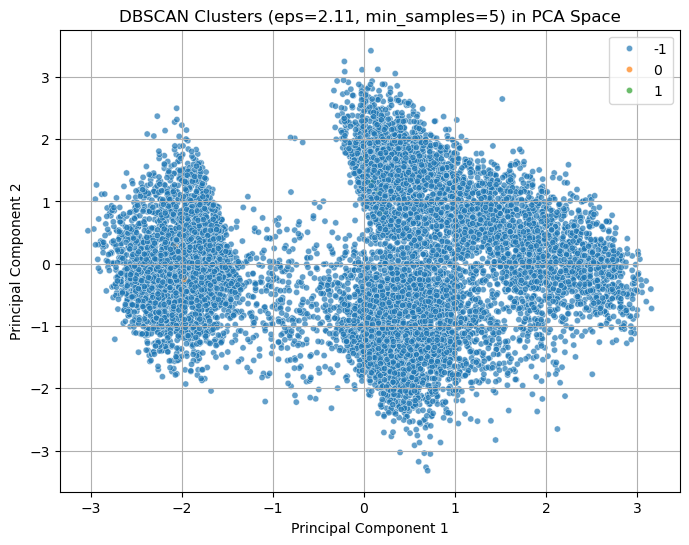

In [27]:
#Visualize
X_pca = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=cluster_labels, palette='tab10', s=20, alpha=0.7, legend="full")
plt.title("DBSCAN Clusters (eps=2.11, min_samples=5) in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Insights: 
- The PCA visualization of the DBSCAN results (with eps=2.11, min_samples=5) reveals that the vast majority of data points were classified as noise (label -1), with only two small, dense clusters identified. This indicates that DBSCAN found limited high-density regions within the dataset, while treating the remaining data as too sparse or irregular to assign to a cluster. The identified clusters appear relatively compact but are not strongly separated in the PCA space, which aligns with the low silhouette score (~−0.15). Overall, this suggests that DBSCAN may not be well-suited for this dataset in its current form, as it detects minimal meaningful structure while discarding most of the data as noise.

In [28]:

dbscan = DBSCAN(eps=2.111111, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

df["DBSCAN_Cluster"] = dbscan_labels

#Recompute feature columns (excluding target and cluster labels)
feature_cols = df.drop(columns=["Heart Disease Status", "DBSCAN_Cluster", "KMeans_Cluster", "Agglo_Cluster"], errors='ignore').columns

#Filter out noise (-1) and compute centroids
centroids = df[df["DBSCAN_Cluster"] != -1].groupby("DBSCAN_Cluster")[feature_cols].mean()

#Show centroids (transposed for readability)
print(centroids.round(2).T)

DBSCAN_Cluster               0     1
Age                       1.01 -1.05
Blood Pressure            0.83  0.93
Cholesterol Level         0.06 -0.77
Exercise Habits           1.00  0.00
BMI                       0.02  0.41
Stress Level              1.80  0.00
Sleep Hours              -0.04  0.28
Sugar Consumption         2.00  0.20
Triglyceride Level       -0.60  0.51
Fasting Blood Sugar      -0.74 -0.37
CRP Level                 0.50 -0.08
Homocysteine Level        0.79  1.26
Gender_Male               1.00  0.00
Smoking_Yes               0.20  0.20
Family Heart Disease_Yes  0.00  0.80
Diabetes_Yes              0.00  0.80
High Blood Pressure_Yes   0.20  1.00
Low HDL Cholesterol_Yes   1.00  0.00
High LDL Cholesterol_Yes  0.20  1.00


Cluster 0 – “Young, Stressed, Sugar-Driven Males”:
- This group appears to be young and highly active but may cope with stress through excessive sugar intake. Despite their lifestyle, they show favorable metabolic markers, possibly due to age or fitness. However, the extremely high stress and sugar consumption could lead to risk over time if unaddressed.

Cluster 1 - “Older, Metabolically At-Risk Individuals”:
- This cluster likely includes older adults with established cardiovascular risks, such as elevated blood pressure, cholesterol, and metabolic syndrome indicators. Their lower exercise and sugar consumption suggest a more sedentary or medically managed profile, but risk remains elevated due to multiple biomarkers and history.


## Fuzzy C-Means

In [29]:
#Hyperparameter testing and results
X = df.drop(columns=["Heart Disease Status"]).values
true_labels = df["Heart Disease Status"].values

c_values = range(2, 10)  # Number of clusters
m_values = np.linspace(1.1, 2.5, 7)  # Fuzziness

results = []

for c in c_values:
    for m in m_values:
        cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(X.T, c=c, m=m, error=0.005, maxiter=1000, init=None)
        labels = np.argmax(u, axis=0)
        
        if len(set(labels)) > 1:  # Skip trivial results
            sil = silhouette_score(X, labels)
        else:
            sil = -1
        
        results.append({
            'c': c,
            'm': round(m, 2),
            'silhouette': sil,
            'fpc': fpc
        })

results_df = pd.DataFrame(results).sort_values(by='silhouette', ascending=False)
results_df.head(10)

,c,m,silhouette,fpc
0,2,1.10,0.122915,0.936510
1,2,1.33,0.115124,0.567844
4,2,2.03,0.113474,0.500000
3,2,1.80,0.113393,0.500000
5,2,2.27,0.112296,0.500000
6,2,2.50,0.105388,0.500000
7,3,1.10,0.098770,0.874020
14,4,1.10,0.097464,0.844955
21,5,1.10,0.084576,0.799230
28,6,1.10,0.077518,0.765607


In [30]:
#Running Fuzzy C-Means with c=2 and m=1.1
#Prep data
X = df.drop(columns=["Heart Disease Status"]).values
true_labels = df["Heart Disease Status"].values

#Run Fuzzy C-Means with best config
c = 2
m = 1.1

cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
    X.T, c=c, m=m, error=0.005, maxiter=1000, init=None)

#Get hard labels (cluster with highest membership)
cluster_labels = np.argmax(u, axis=0)

#Evaluate
ari = adjusted_rand_score(true_labels, cluster_labels)
sil = silhouette_score(X, cluster_labels)

print("Fuzzy C-Means Clustering")
print("Number of clusters:", c)
print("Fuzziness (m):", m)
print("Adjusted Rand Index (ARI):", round(ari, 4))
print("Silhouette Score:", round(sil, 4))
print("Fuzzy Partition Coefficient (FPC):", round(fpc, 4))



Fuzzy C-Means Clustering
Number of clusters: 2
Fuzziness (m): 1.1
Adjusted Rand Index (ARI): 0.0018
Silhouette Score: 0.1229
Fuzzy Partition Coefficient (FPC): 0.9365


Insights: 
The Fuzzy C-Means clustering results with two clusters and a fuzziness parameter of 1.1 reveal that the algorithm identified moderately distinct groupings within the data. The Silhouette Score of 0.1229 suggests a reasonable degree of internal cohesion within clusters and separation between them, indicating that the identified clusters have some structural validity. The Fuzzy Partition Coefficient (FPC) of 0.9365 is notably high, reflecting that most data points had strong memberships to a single cluster, even though FCM allows for soft assignments. However, the Adjusted Rand Index (ARI) of 0.0018 shows that these clusters do not align meaningfully with the actual heart disease labels in the dataset. In essence, while the model was able to find structured subgroups in the data, these do not correspond to the true health outcome labels, implying that the clusters may be capturing behavioral, demographic, or metabolic patterns unrelated to diagnosed disease status.

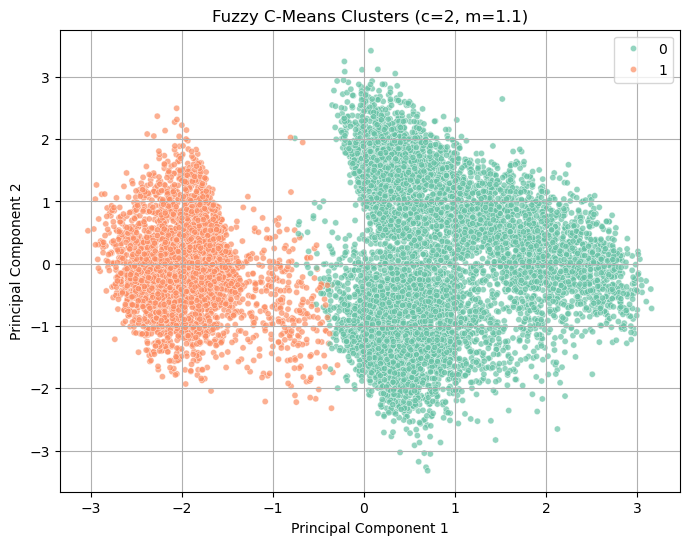

In [31]:
#Visualize
X_pca = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=cluster_labels, palette='Set2', s=20, alpha=0.7)
plt.title("Fuzzy C-Means Clusters (c=2, m=1.1)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Insights: 
- This PCA plot of Fuzzy C-Means clustering (with c=2 and m=1.1) shows two visually distinct clusters projected in two dimensions. Cluster 0 (in green) is relatively compact and concentrated on the left, while Cluster 1 (in orange) occupies a broader region on the right. The clean visual separation suggests that the algorithm successfully identified two meaningful groupings in the feature space, despite allowing for soft cluster memberships. However, as previously noted, the low Adjusted Rand Index implies that these visual clusters don’t closely correspond to heart disease labels. Overall, the plot supports the silhouette score finding: moderate separation, but not disease-aligned.

In [32]:
cluster_centers = pd.DataFrame(cntr, columns=df.drop(columns=["Heart Disease Status"]).columns)
cluster_centers.index = [f"Group {i}" for i in range(c)]
display(cluster_centers)

,Age,Blood Pressure,Cholesterol Level,Exercise Habits,BMI,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,...,Gender_Male,Smoking_Yes,Family Heart Disease_Yes,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,KMeans_Cluster,Agglo_Cluster,DBSCAN_Cluster
Group 0,-0.019398,-0.004883,0.029924,0.993312,0.027437,0.994307,0.025874,1.002749,0.329313,0.416071,...,0.503911,0.515059,0.494778,0.493383,0.506197,0.505891,0.494770,1.546332,1.921199,-0.998687
Group 1,0.037348,0.009622,-0.057945,1.050489,-0.054868,0.997032,-0.045224,0.968639,-0.641859,-0.814458,...,0.499268,0.514346,0.502718,0.498573,0.501737,0.495779,0.491662,0.151594,0.152979,-0.998190


Cluster 0 - “Elevated Biomarkers with Average Lifestyle”:
- This cluster represents individuals who lead a generally average lifestyle—with balanced exercise, sleep, and stress levels—but show slightly elevated metabolic markers, particularly triglycerides and fasting blood sugar. While not currently high-risk, these trends may indicate early warning signs of developing metabolic issues. The balanced demographic profile and average habits suggest this group forms a broad, heterogeneous baseline, but would benefit from preventive monitoring to avoid progression toward higher risk.

Cluster 1 - “Active Lifestyle, Lower Metabolic Risk”: 
- This cluster reflects a group of health-conscious individuals who engage in regular physical activity and maintain a favorable metabolic profile. With above-average exercise levels, slightly lower BMI, and reduced triglyceride and fasting blood sugar levels, they show signs of lower cardiometabolic risk. Their health-risk indicators are also minimal, reinforcing a low-risk, well-managed profile. The consistency across clustering methods suggests this is a distinct, core group that exemplifies preventive health behaviors and metabolic stability.


## Gaussian Mixture Model


In [33]:
#Hypertuning GMM with results 
X = df.drop(columns=["Heart Disease Status"])

n_components_range = range(2, 10)
covariance_types = ['full', 'tied', 'diag', 'spherical']

results = []

for n in n_components_range:
    for cov in covariance_types:
        try:
            gmm = GaussianMixture(n_components=n, covariance_type=cov, random_state=42)
            labels = gmm.fit_predict(X)

            if len(set(labels)) > 1:
                sil = silhouette_score(X, labels)
            else:
                sil = -1  # Not useful

            results.append({
                'n_components': n,
                'covariance_type': cov,
                'silhouette': sil
            })
        except:
            # Catch any numerical errors during GMM fitting
            results.append({
                'n_components': n,
                'covariance_type': cov,
                'silhouette': -1
            })

# Show top configurations
results_df = pd.DataFrame(results).sort_values(by='silhouette', ascending=False)
results_df.head(10)

,n_components,covariance_type,silhouette
3,2,spherical,0.122960
0,2,full,0.120789
2,2,diag,0.120789
1,2,tied,0.119993
11,4,spherical,0.098928
7,3,spherical,0.098705
9,4,tied,0.097643
4,3,full,0.096964
6,3,diag,0.096964
8,4,full,0.096570


In [34]:
#Running GMM with n_components=2, covariance_type='spherical'

#Prepare the data
X = df.drop(columns=["Heart Disease Status"])
true_labels = df["Heart Disease Status"]

#Fit GMM with best config (n=2, spherical covariance)
gmm = GaussianMixture(n_components=2, covariance_type='spherical', random_state=42)
gmm_labels = gmm.fit_predict(X)

#Evaluate performance
sil = silhouette_score(X, gmm_labels)
ari = adjusted_rand_score(true_labels, gmm_labels)

print("Gaussian Mixture Model (Best Config)")
print("n_components = 2, covariance_type = 'spherical'")
print("Silhouette Score:", round(sil, 4))
print("Adjusted Rand Index (ARI):", round(ari, 4))



Gaussian Mixture Model (Best Config)
n_components = 2, covariance_type = 'spherical'
Silhouette Score: 0.123
Adjusted Rand Index (ARI): -0.0001


Insights: 
- The GMM identified two clusters with a Silhouette Score of 0.123, indicating moderate internal cohesion and some degree of separation between clusters. However, the Adjusted Rand Index (ARI) of -0.0001 shows that these clusters do not align meaningfully with the true heart disease status labels. In other words, while the algorithm found statistically distinct groups in the data based on feature patterns, these groupings do not correspond to clinical outcomes in a useful way. This result is consistent with other unsupervised methods applied to the same dataset, suggesting that heart disease status may not be strongly separable using clustering alone.

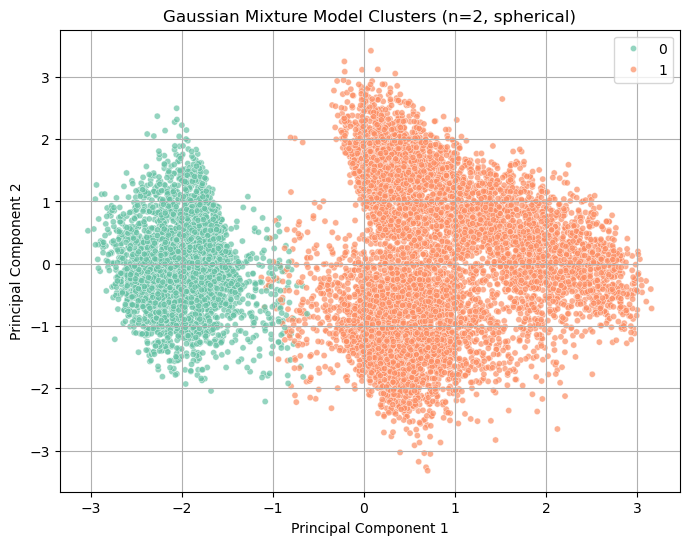

In [35]:
#Visualize
X_pca = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=gmm_labels, palette='Set2', s=20, alpha=0.7)
plt.title("Gaussian Mixture Model Clusters (n=2, spherical)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Insights: 
- The Gaussian Mixture Model (GMM) clustering with 2 components and spherical covariance revealed moderately cohesive groupings within the dataset, as indicated by a silhouette score of 0.123. This suggests that while the clusters exhibit some internal consistency, the overall separation between groups is limited. However, the Adjusted Rand Index (ARI) of -0.0001 shows that the identified clusters do not align meaningfully with the actual heart disease status labels, implying that the GMM’s statistical partitioning fails to capture the clinically relevant structure of the data. The PCA visualization supports this, showing visually distinct groupings, but without correspondence to true diagnostic categories. Overall, while the GMM finds patterns in the data’s shape, it lacks predictive or clinical utility in its current form.

In [36]:
df["GMM_Cluster"] = gmm_labels

cluster_means = df.groupby("GMM_Cluster")[X.columns].mean()
display(cluster_means)

,Age,Blood Pressure,Cholesterol Level,Exercise Habits,BMI,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,...,Gender_Male,Smoking_Yes,Family Heart Disease_Yes,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,KMeans_Cluster,Agglo_Cluster,DBSCAN_Cluster
GMM_Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.040086,0.010763,-0.062565,1.053841,-0.058069,1.000000,-0.027866,0.965529,-0.687556,-0.886905,...,0.500000,0.516087,0.500657,0.49803,0.499015,0.494091,0.488838,0.049573,0.018713,-0.998359
1,-0.017559,-0.004714,0.027405,0.994536,0.025436,0.992954,0.012206,1.002157,0.301164,0.388483,...,0.503164,0.514236,0.496117,0.49396,0.507334,0.506183,0.495974,1.527035,1.895887,-0.998562


Cluster 0 - “Health-Conscious, Lower-Risk Individuals”: 
- This cluster represents a core group with strong preventive health behaviors and low metabolic risk. Characterized by high physical activity, lower BMI, and markedly reduced triglyceride and blood sugar levels, these individuals demonstrate a favorable cardiometabolic profile. They show fewer lifestyle and health risk markers, such as lower smoking and diabetes rates. With centroids near zero for demographics, there’s no clear gender or background bias. The group’s consistent appearance in low cluster IDs across methods indicates a stable, low-risk population segment.

Cluster 1 - “Elevated Cardiometabolic Risk”:
- This cluster reflects a moderate-risk group with early warning signs of cardiometabolic issues. Members show elevated triglyceride (+0.30) and fasting blood sugar (+0.39) levels, combined with slightly lower exercise and higher BMI, suggesting a drift away from optimal metabolic health. Though stress levels are average, several health-related flags, including diabetes, LDL cholesterol, and family history, are more pronounced, indicating increased cardiovascular risk. Their alignment with higher cluster IDs in KMeans and Agglomerative Clustering (~1.5–1.9) suggests this is a larger, more complex group potentially requiring targeted interventions.

## CURE

In [37]:
#Hypertuning CURE and results 

#Sample 500 rows for quick testing
df_sample = df.sample(n=500, random_state=42)

#Define features to use
feature_cols = [
    "Age", "Blood Pressure", "Cholesterol Level", "BMI", "Sleep Hours",
    "Triglyceride Level", "Fasting Blood Sugar", "CRP Level", "Homocysteine Level",
    "Gender_Male", "Smoking_Yes", "Family Heart Disease_Yes", "Diabetes_Yes",
    "High Blood Pressure_Yes", "Low HDL Cholesterol_Yes", "High LDL Cholesterol_Yes"
]

#Prep data
X = df_sample[feature_cols].values.tolist()
X_np = np.array(X)

#Reduced search space
cluster_options = [2, 3]
rep_points_options = [5, 10]
compression_options = [0.2, 0.5]

#Initialize best scores
best_score = -1
best_db_score = float('inf')
best_params = {}
best_db_params = {}
results = []

for k in cluster_options:
    for reps in rep_points_options:
        for comp in compression_options:
            try:
                model = cure(data=X, number_cluster=k,
                             number_represent_points=reps, compression=comp, ccore=False)
                model.process()
                clusters = model.get_clusters()

                if len(clusters) <= 1:
                    continue

                #Assign labels
                labels = np.zeros(len(X_np))
                for cluster_idx, cluster in enumerate(clusters):
                    for point_idx in cluster:
                        labels[point_idx] = cluster_idx

                #Evaluation metrics
                sil_score = silhouette_score(X_np, labels)
                db_score = davies_bouldin_score(X_np, labels)

                results.append({
                    'clusters': k,
                    'rep_points': reps,
                    'compression': comp,
                    'silhouette': sil_score,
                    'davies_bouldin': db_score
                })

                #Update best scores
                if sil_score > best_score:
                    best_score = sil_score
                    best_params = {'k': k, 'reps': reps, 'comp': comp}

                if db_score < best_db_score:
                    best_db_score = db_score
                    best_db_params = {'k': k, 'reps': reps, 'comp': comp}

            except Exception as e:
                print(f"⚠️ Skipped k={k}, reps={reps}, comp={comp} due to error: {e}")
                continue

# Output results
print(f"\nBest Silhouette Score: {best_score:.4f}")
print(f"Best Params (Silhouette), Clusters: {best_params['k']}, Rep Points: {best_params['reps']}, Compression: {best_params['comp']}")
print(f"\nBest Davies-Bouldin Score: {best_db_score:.4f}")
print(f"Best Params (DB Score), Clusters: {best_db_params['k']}, Rep Points: {best_db_params['reps']}, Compression: {best_db_params['comp']}")

# Display sorted results
df_results = pd.DataFrame(results)
display(df_results.sort_values(by="silhouette", ascending=False))


Best Silhouette Score: 0.1552
Best Params (Silhouette), Clusters: 2, Rep Points: 5, Compression: 0.2

Best Davies-Bouldin Score: 0.7191
Best Params (DB Score), Clusters: 2, Rep Points: 5, Compression: 0.2


,clusters,rep_points,compression,silhouette,davies_bouldin
0,2,5,0.2,0.155212,0.719103
1,2,5,0.5,0.146837,0.729385
3,2,10,0.5,0.146837,0.729385
2,2,10,0.2,0.077566,0.833439
7,3,10,0.5,0.055613,0.768092
5,3,5,0.5,0.031323,0.790730
4,3,5,0.2,0.020009,0.818191
6,3,10,0.2,0.013431,1.045679


In [38]:
#Running best results of CURE 
#Prep data
X = df.drop(columns=["Heart Disease Status"]).values

#Run CURE with best parameters
cure_model = cure(data=X, number_cluster=2, number_represent_points=5, compression=0.2, ccore=False)
cure_model.process()
clusters = cure_model.get_clusters()

#Assign labels
labels = np.zeros(len(X))
for cluster_id, indices in enumerate(clusters):
    for idx in indices:
        labels[idx] = cluster_id

#Evaluate
sil_score = silhouette_score(X, labels)
db_score = davies_bouldin_score(X, labels)

print("Final CURE Results:")
print("Silhouette Score:", round(sil_score, 4))
print("Davies-Bouldin Score:", round(db_score, 4))

Final CURE Results:
Silhouette Score: 0.0791
Davies-Bouldin Score: 0.8375


Insights:
- The CURE algorithm, applied with the best-tuned parameters (2 clusters, 5 representative points, compression = 0.2), achieved a Silhouette Score of 0.0791 and a Davies-Bouldin Score of 0.8375. These scores suggest that while the clustering algorithm was able to form some structure within the data, the clusters are not highly distinct or compact, implying overlapping characteristics between groups. Nonetheless, the clustering process may still reveal useful patterns or subpopulations when examining cluster profiles in the context of health risk factors.

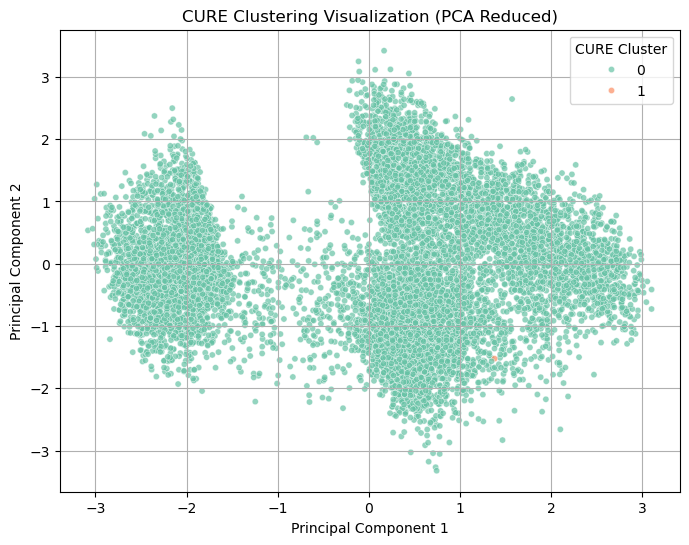

In [42]:
#Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#Plot the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=labels.astype(int), palette='Set2', s=20, alpha=0.7)

plt.title("CURE Clustering Visualization (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='CURE Cluster')
plt.grid(True)
plt.show()

Insights: 
- This PCA visualization of the final CURE clustering results shows two clusters projected into two principal components. While the clusters slightly separate in shape, there is considerable overlap, suggesting the groups are not clearly distinguishable in reduced-dimensional space. The softness of the boundaries aligns with the relatively low silhouette score (0.0791) and moderate Davies-Bouldin score (0.8375), indicating weak cohesion and separation. However, some structural grouping is visible, particularly toward the left and right sides of the plot, which may reflect subtle differences in health profiles.

In [43]:
df["CURE_Cluster"] = labels.astype(int)

cluster_profiles = df.groupby("CURE_Cluster").mean().round(2)
display(cluster_profiles.T)

CURE_Cluster,0,1
Age,-0.00,1.69
Blood Pressure,-0.00,1.21
Cholesterol Level,-0.00,0.27
Exercise Habits,1.01,0.00
BMI,0.00,-1.55
Stress Level,1.00,0.00
Sleep Hours,-0.00,1.69
Sugar Consumption,0.99,2.00
Triglyceride Level,-0.00,0.41
Fasting Blood Sugar,-0.00,1.65


Cluster 0 - “Active but Stressed Individuals with Moderate Risk”: 
- This cluster consists of individuals who engage in high levels of physical activity and maintain average biometric markers like BMI, blood pressure, and cholesterol. However, they report elevated stress levels and moderately high sugar consumption, which could point to stress-related compensatory behaviors such as stress eating. Their smoking prevalence, diabetes rates, and family history of heart disease are all around 50%, suggesting a mixed-risk profile. While not immediately at high medical risk, this group shows early lifestyle-based warning signs that may predispose them to future cardiometabolic issues if left unaddressed.

Cluster 1 - “Young, Obese Non-Smokers with High Glucose & Sugar Intake”:
- Members of this cluster show a stark metabolic risk profile, with extremely high sugar consumption, fasting blood sugar, and inflammatory markers like CRP and homocysteine. Despite not smoking and being predominantly non-male, they exhibit 100% rates for diabetes and family history of heart disease. Interestingly, their average BMI appears very low, which may reflect lean individuals with hidden metabolic dysfunction — a potential sign of lean diabetes or other underlying conditions. This group reflects a nontraditional risk cluster that may be overlooked by appearance but faces significant health concerns internally.


## Summary Comparison

- Fuzzy C-Means and GMM had the highest silhouette scores (~0.123), indicating the best-defined clusters in terms of cohesion and separation. However, their ARI scores are close to 0, meaning poor alignment with the true heart disease labels, suggesting that the underlying structure found by these methods may not correspond to the target outcome.

- CURE achieved a moderate silhouette (0.0791) and reasonable Davies-Bouldin score (0.8375), showing it captures some structure with flexibility for non-convex shapes, though it still lacks strong separation.

- K-Means and Agglomerative clustering, with silhouette scores between 0.04 and 0.07, yielded the weakest clustering definition. Their ARI scores near 0 suggest they don’t match the target well either.

- DBSCAN failed to cluster the data meaningfully under tested parameters, labeling most points as noise, likely due to the high dimensionality and lack of strong density-based structure.

While no clustering algorithm achieved strong alignment with the true heart disease labels (as reflected by low Adjusted Rand Index scores across the board), Fuzzy C-Means and Gaussian Mixture Models performed the best in terms of internal clustering quality, each achieving the highest Silhouette Scores (~0.123). These results suggest that while their clusters are well-formed in terms of cohesion and separation, they do not align closely with known clinical outcomes. The CURE algorithm, although slightly weaker in Silhouette Score (0.0791), offered more flexible clustering and a solid Davies-Bouldin Score (0.8375), indicating moderately good intra-cluster similarity and inter-cluster separation. Traditional methods like K-Means and Agglomerative Clustering showed limited performance, and DBSCAN struggled significantly due to the high dimensionality and diffuse nature of the data, misclassifying most points as noise.

In conclusion, although unsupervised methods consistently identified stable latent subgroups within the patient population, these segments did not align with diagnosed heart disease outcomes. The dominant structure reflects behavioral and metabolic variation rather than disease classification. This suggests that heart disease risk in this dataset is likely driven by nonlinear interactions among risk factors rather than geometric separability in feature space.